# 📊 Phân Tích Sơ Bộ Dataset Ostovar — 75 Synthetic Event Logs

**Mục tiêu notebook này:**
- Khám phá cấu trúc và đặc điểm của 75 event logs tổng hợp (synthetic) từ benchmark Ostovar.
- Phân loại các loại concept drift: Atomic, Composite, Nested.
- So sánh kích thước, số trace, số activity giữa các nhóm log.
- Chuẩn bị nền tảng cho các thực nghiệm drift detection.

---

**Nguồn gốc dataset:**
> Ostovar et al. (2016). *Business Process Drift Detection using Hierarchical Clustering* — synthetic event logs được sinh bằng PLG2 với các loại drift có kiểm soát (controlled drift).

**Cấu trúc tên file:**
```
{Level}_{DriftType}_output_{DriftType}_{noise}.xes.gz
```
- **Level**: Atomic | Composite | Nested
- **DriftType**: ConditionalMove, ConditionalRemoval, ConditionalToSequence, Frequency, Loop, ParallelMove, ParallelRemoval, ParallelToSequence, SerialMove, SerialRemoval, Skip, Substitute, Swap | IOR, IRO, OIR, ORI, RIO, ROI
- **Noise suffix**: *(none)* = baseline, `_2` = noise 2%, `_5` = noise 5%

---

## 0. Cài Đặt & Import Thư Viện

In [ ]:
# Kiểm tra và cài đặt thư viện cần thiết
import subprocess, sys

def install_if_missing(package):
    try:
        __import__(package)
    except ImportError:
        print(f"⚙️  Đang cài đặt {package}...")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package, '-q'])
        print(f"✅ {package} đã được cài đặt.")

install_if_missing('pm4py')
install_if_missing('pandas')
install_if_missing('numpy')
install_if_missing('matplotlib')
install_if_missing('seaborn')
install_if_missing('tqdm')
install_if_missing('plotly')

print("\n✅ Tất cả thư viện đã sẵn sàng!")

In [ ]:
import os
import re
import gzip
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from tqdm import tqdm
from pathlib import Path
import pm4py
from pm4py.objects.log.importer.xes import importer as xes_importer

warnings.filterwarnings('ignore')

# Matplotlib style
plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = ['#4361EE', '#F72585', '#4CC9F0', '#7209B7', '#3A0CA3', '#F4A261', '#2EC4B6']
sns.set_palette(PALETTE)

print(f"✅ pm4py version: {pm4py.__version__}")
print(f"✅ pandas version: {pd.__version__}")

## 1. Tổng Quan Dataset — Phân Loại 75 File Log

In [ ]:
# ──────────────────────────────────────────────────────────────────
# ĐƯỜNG DẪN — Chỉnh lại nếu cần
# ──────────────────────────────────────────────────────────────────
LOG_DIR = Path("../EvaluationLogs/Ostovar")

assert LOG_DIR.exists(), f"❌ Không tìm thấy thư mục: {LOG_DIR.resolve()}"

# Lấy danh sách tất cả file .xes.gz
all_files = sorted(LOG_DIR.glob("*.xes.gz"))
print(f"🗂️  Tổng số file tìm thấy: {len(all_files)}")

# Regex parse tên file
# Pattern: Level_DriftType_output_DriftType[_noise].xes.gz
pattern = re.compile(
    r'^(?P<level>Atomic|Composite|Nested)_'
    r'(?P<drift_type>[A-Za-z]+)_output_'
    r'(?P<drift_type2>[A-Za-z]+)'
    r'(?:_(?P<noise>\d+))?\.xes\.gz$'
)

catalog = []
for f in all_files:
    m = pattern.match(f.name)
    if m:
        noise_raw = m.group('noise')
        catalog.append({
            'filename': f.name,
            'filepath': f,
            'level': m.group('level'),
            'drift_type': m.group('drift_type'),
            'noise_pct': int(noise_raw) if noise_raw else 0,
            'size_kb': round(f.stat().st_size / 1024, 1),
        })
    else:
        print(f"⚠️  Không parse được: {f.name}")

catalog_df = pd.DataFrame(catalog)
print(f"\n📋 Catalog tạo thành công: {len(catalog_df)} dòng")
catalog_df.head(10)

In [ ]:
# Thống kê phân bổ theo cấp độ và loại drift
print("═" * 60)
print("📊 PHÂN BỔ THEO CẤP ĐỘ DRIFT")
print("═" * 60)
print(catalog_df['level'].value_counts().to_string())

print("\n" + "═" * 60)
print("📊 PHÂN BỔ THEO LOẠI DRIFT (drift_type)")
print("═" * 60)
print(catalog_df.groupby(['level', 'drift_type'])['filename'].count().to_string())

print("\n" + "═" * 60)
print("📊 PHÂN BỔ THEO % NOISE")
print("═" * 60)
print(catalog_df['noise_pct'].value_counts().sort_index().to_string())

In [ ]:
# Bảng tổng quan đầy đủ
pivot_count = catalog_df.pivot_table(
    index=['level', 'drift_type'],
    columns='noise_pct',
    values='filename',
    aggfunc='count'
).fillna(0).astype(int)
pivot_count.columns = [f'noise={c}%' for c in pivot_count.columns]
print("\n📋 Ma trận phân bổ file theo (Level × DriftType × Noise):")
display(pivot_count)

## 2. Trực Quan Hóa Cấu Trúc Dataset

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Cấu Trúc Tổng Quan Dataset Ostovar (75 Logs)', fontsize=15, fontweight='bold', y=1.02)

# ── Plot 1: Donut chart theo Level ──
ax = axes[0]
level_counts = catalog_df['level'].value_counts()
colors = ['#4361EE', '#F72585', '#4CC9F0']
wedges, texts, autotexts = ax.pie(
    level_counts,
    labels=level_counts.index,
    autopct='%1.0f%%',
    colors=colors,
    startangle=90,
    pctdistance=0.8,
    wedgeprops=dict(width=0.5)
)
for autotext in autotexts:
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')
ax.set_title('Phân Bổ Theo Level Drift', fontsize=12, pad=15)

# ── Plot 2: Bar chart theo DriftType ──
ax = axes[1]
type_counts = catalog_df['drift_type'].value_counts().sort_values(ascending=True)
colors_bar = [PALETTE[0] if catalog_df[catalog_df['drift_type'] == t]['level'].iloc[0] == 'Atomic'
              else (PALETTE[1] if catalog_df[catalog_df['drift_type'] == t]['level'].iloc[0] == 'Composite'
                    else PALETTE[2])
              for t in type_counts.index]
bars = ax.barh(range(len(type_counts)), type_counts.values, color=colors_bar, alpha=0.85, edgecolor='white')
ax.set_yticks(range(len(type_counts)))
ax.set_yticklabels(type_counts.index, fontsize=9)
ax.set_xlabel('Số lượng file', fontsize=10)
ax.set_title('Số File Theo Loại Drift', fontsize=12)
for i, v in enumerate(type_counts.values):
    ax.text(v + 0.05, i, str(v), va='center', fontsize=10, fontweight='bold')

legend_patches = [
    mpatches.Patch(color=PALETTE[0], label='Atomic'),
    mpatches.Patch(color=PALETTE[1], label='Composite'),
    mpatches.Patch(color=PALETTE[2], label='Nested'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)

# ── Plot 3: Kích thước file theo Level ──
ax = axes[2]
for i, (level, grp) in enumerate(catalog_df.groupby('level')):
    ax.boxplot(
        grp['size_kb'],
        positions=[i],
        widths=0.4,
        patch_artist=True,
        boxprops=dict(facecolor=colors[i], alpha=0.7),
        medianprops=dict(color='white', linewidth=2),
        whiskerprops=dict(color=colors[i]),
        capprops=dict(color=colors[i]),
        flierprops=dict(marker='o', color=colors[i], alpha=0.5)
    )
ax.set_xticks(range(len(catalog_df['level'].unique())))
ax.set_xticklabels(catalog_df['level'].unique(), fontsize=10)
ax.set_ylabel('Kích thước file (KB)', fontsize=10)
ax.set_title('Phân Bổ Kích Thước File Theo Level', fontsize=12)

plt.tight_layout()
plt.savefig('ostovar_structure_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Đã lưu: ostovar_structure_overview.png")

## 3. Đọc & Phân Tích Mẫu Event Logs

> **Chiến lược:** Đọc đại diện mỗi `(level × drift_type × noise=0)` — tổng ~25 logs để tránh tốn RAM.
> Với mỗi log, trích xuất: số trace, số event, số activity, khoảng thời gian, trace length stats.

In [ ]:
def extract_log_stats(filepath):
    """
    Đọc một file XES.GZ và trích xuất các thống kê cơ bản.
    Trả về dict với các KPI quan trọng.
    """
    try:
        log = xes_importer.apply(str(filepath))
        
        n_traces   = len(log)
        n_events   = sum(len(trace) for trace in log)
        trace_lens = [len(trace) for trace in log]
        
        # Tập hợp activities
        activities = set()
        timestamps = []
        for trace in log:
            for event in trace:
                activities.add(event.get('concept:name', 'UNKNOWN'))
                ts = event.get('time:timestamp')
                if ts:
                    timestamps.append(ts)
        
        # Khoảng thời gian
        if timestamps:
            ts_sorted = sorted(timestamps)
            duration_days = (ts_sorted[-1] - ts_sorted[0]).days
        else:
            duration_days = None
        
        return {
            'n_traces':         n_traces,
            'n_events':         n_events,
            'n_activities':     len(activities),
            'activities':       sorted(activities),
            'trace_len_min':    min(trace_lens),
            'trace_len_max':    max(trace_lens),
            'trace_len_mean':   round(np.mean(trace_lens), 2),
            'trace_len_std':    round(np.std(trace_lens), 2),
            'trace_len_median': np.median(trace_lens),
            'duration_days':    duration_days,
            'status':           'OK'
        }
    except Exception as e:
        return {'status': f'ERROR: {str(e)}'}

print("✅ Hàm extract_log_stats đã sẵn sàng.")

In [ ]:
# ──────────────────────────────────────────────────────────────────
# Chọn sample: baseline (noise=0) của tất cả drift types
# ──────────────────────────────────────────────────────────────────
sample_df = catalog_df[catalog_df['noise_pct'] == 0].copy()
print(f"📂 Số log sẽ đọc (baseline noise=0): {len(sample_df)}")
print("   Đây sẽ mất vài phút, vui lòng chờ...\n")

stats_list = []
for _, row in tqdm(sample_df.iterrows(), total=len(sample_df), desc="🔍 Đọc logs"):
    stats = extract_log_stats(row['filepath'])
    stats['filename']   = row['filename']
    stats['level']      = row['level']
    stats['drift_type'] = row['drift_type']
    stats['noise_pct']  = row['noise_pct']
    stats['size_kb']    = row['size_kb']
    stats_list.append(stats)

stats_df = pd.DataFrame(stats_list)
print(f"\n✅ Đã đọc xong {len(stats_df)} logs.")
stats_df[['level', 'drift_type', 'n_traces', 'n_events', 'n_activities',
          'trace_len_mean', 'trace_len_std', 'duration_days', 'status']].head(10)

In [ ]:
# Kiểm tra lỗi (nếu có)
errors = stats_df[stats_df['status'] != 'OK']
if len(errors) > 0:
    print(f"⚠️  Có {len(errors)} log bị lỗi khi đọc:")
    display(errors[['filename', 'status']])
else:
    print("✅ Tất cả logs đọc thành công, không có lỗi.")

# Thống kê tổng hợp
ok_df = stats_df[stats_df['status'] == 'OK'].copy()
print(f"\n📊 THỐNG KÊ TỔNG HỢP (n={len(ok_df)} logs baseline):")
print("─" * 55)
print(f"  Tổng số trace:       {ok_df['n_traces'].sum():>10,}")
print(f"  Tổng số event:       {ok_df['n_events'].sum():>10,}")
print(f"  Trung bình n_traces: {ok_df['n_traces'].mean():>10.1f}")
print(f"  Trung bình n_events: {ok_df['n_events'].mean():>10.1f}")
print(f"  n_activities min:    {ok_df['n_activities'].min():>10}")
print(f"  n_activities max:    {ok_df['n_activities'].max():>10}")
print(f"  Trace length mean:   {ok_df['trace_len_mean'].mean():>10.2f}")
print(f"  Trace length std:    {ok_df['trace_len_std'].mean():>10.2f}")

## 4. So Sánh Đặc Tính Các Nhóm Drift

In [ ]:
# ── Bảng thống kê theo Level ──
print("📊 Thống kê theo LEVEL DRIFT:")
level_summary = ok_df.groupby('level').agg(
    n_logs        = ('filename', 'count'),
    avg_traces    = ('n_traces', 'mean'),
    avg_events    = ('n_events', 'mean'),
    avg_activities= ('n_activities', 'mean'),
    avg_trace_len = ('trace_len_mean', 'mean'),
    avg_duration  = ('duration_days', 'mean'),
    avg_size_kb   = ('size_kb', 'mean'),
).round(2)
display(level_summary)

print("\n📊 Thống kê theo DRIFT TYPE:")
type_summary = ok_df.groupby(['level', 'drift_type']).agg(
    avg_traces    = ('n_traces', 'mean'),
    avg_events    = ('n_events', 'mean'),
    avg_activities= ('n_activities', 'mean'),
    avg_trace_len = ('trace_len_mean', 'mean'),
).round(2)
display(type_summary)

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('So Sánh Đặc Tính Logs Theo Level & Drift Type', fontsize=15, fontweight='bold')

level_colors = {'Atomic': PALETTE[0], 'Composite': PALETTE[1], 'Nested': PALETTE[2]}
ok_df['color'] = ok_df['level'].map(level_colors)

# ── Plot 1: n_traces theo drift_type × level ──
ax = axes[0, 0]
for level, grp in ok_df.groupby('level'):
    ax.scatter(grp['drift_type'], grp['n_traces'],
               color=level_colors[level], label=level, s=120, alpha=0.85, zorder=3)
ax.set_xlabel('Drift Type', fontsize=10)
ax.set_ylabel('Số Traces', fontsize=10)
ax.set_title('Số Trace Theo Loại Drift', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Level', fontsize=9)

# ── Plot 2: n_activities theo level ──
ax = axes[0, 1]
ok_df.boxplot(
    column='n_activities',
    by='level',
    ax=ax,
    patch_artist=True,
    boxprops=dict(facecolor='#4361EE', alpha=0.6),
    medianprops=dict(color='#F72585', linewidth=2.5)
)
ax.set_xlabel('Level', fontsize=10)
ax.set_ylabel('Số Activities', fontsize=10)
ax.set_title('Số Activity Theo Level', fontsize=12)
plt.sca(ax); plt.title('Số Activity Theo Level', fontsize=12)

# ── Plot 3: trace_len_mean ──
ax = axes[1, 0]
for level, grp in ok_df.groupby('level'):
    ax.scatter(grp['drift_type'], grp['trace_len_mean'],
               color=level_colors[level], label=level, s=120, alpha=0.85, marker='D', zorder=3)
ax.set_xlabel('Drift Type', fontsize=10)
ax.set_ylabel('Avg Trace Length', fontsize=10)
ax.set_title('Độ Dài Trace Trung Bình Theo Loại Drift', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Level', fontsize=9)

# ── Plot 4: size_kb theo level ──
ax = axes[1, 1]
for i, (level, grp) in enumerate(ok_df.groupby('level')):
    color = list(level_colors.values())[i]
    ax.bar(grp['drift_type'], grp['size_kb'],
           color=color, alpha=0.75, label=level, edgecolor='white')
ax.set_xlabel('Drift Type', fontsize=10)
ax.set_ylabel('Kích Thước File (KB)', fontsize=10)
ax.set_title('Kích Thước File Theo Loại Drift', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Level', fontsize=9)

plt.tight_layout()
plt.savefig('ostovar_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Đã lưu: ostovar_comparison.png")

## 5. Phân Tích Sâu: Ảnh Hưởng Của Noise Đến Đặc Tính Log

In [ ]:
# ──────────────────────────────────────────────────────────────────
# Đọc TẤT CẢ 75 logs để so sánh noise effect
# Lưu ý: có thể mất ~10-20 phút nếu RAM < 16GB
# Đặt READ_ALL_LOGS = False để bỏ qua bước này
# ──────────────────────────────────────────────────────────────────
READ_ALL_LOGS = True  # ← đổi thành False để skip

if READ_ALL_LOGS:
    print(f"📂 Đọc toàn bộ {len(catalog_df)} logs...")
    all_stats_list = []
    for _, row in tqdm(catalog_df.iterrows(), total=len(catalog_df), desc="🔍 Đọc tất cả logs"):
        stats = extract_log_stats(row['filepath'])
        stats['filename']   = row['filename']
        stats['level']      = row['level']
        stats['drift_type'] = row['drift_type']
        stats['noise_pct']  = row['noise_pct']
        stats['size_kb']    = row['size_kb']
        all_stats_list.append(stats)
    
    all_stats_df = pd.DataFrame(all_stats_list)
    # Lưu cache để tái sử dụng
    all_stats_df.drop(columns=['activities'], errors='ignore').to_csv(
        'ostovar_all_stats_cache.csv', index=False
    )
    print(f"✅ Đã đọc {len(all_stats_df)} logs. Cache lưu tại ostovar_all_stats_cache.csv")
else:
    # Load từ cache nếu đã có
    cache_path = Path('ostovar_all_stats_cache.csv')
    if cache_path.exists():
        all_stats_df = pd.read_csv(cache_path)
        print(f"⚡ Loaded from cache: {len(all_stats_df)} records")
    else:
        all_stats_df = stats_df.copy()  # fallback sang baseline
        print("⚠️  Không có cache, dùng dữ liệu baseline (noise=0) thay thế.")

In [ ]:
# So sánh n_traces theo noise level
all_ok = all_stats_df[all_stats_df['status'] == 'OK'].copy()

noise_comparison = all_ok.groupby(['level', 'noise_pct']).agg(
    avg_traces      = ('n_traces', 'mean'),
    avg_events      = ('n_events', 'mean'),
    avg_trace_len   = ('trace_len_mean', 'mean'),
    avg_trace_std   = ('trace_len_std', 'mean'),
    avg_activities  = ('n_activities', 'mean'),
).round(2).reset_index()

print("📊 So sánh đặc tính log theo cấp độ noise:")
display(noise_comparison)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Ảnh Hưởng Của Noise Đến Đặc Tính Event Logs', fontsize=14, fontweight='bold')

metrics = [
    ('avg_traces',    'Số Trace Trung Bình'),
    ('avg_events',    'Số Event Trung Bình'),
    ('avg_trace_len', 'Độ Dài Trace Trung Bình'),
]

noise_labels = {0: '0% (Baseline)', 2: '2% Noise', 5: '5% Noise'}
noise_palette = {0: PALETTE[0], 2: PALETTE[3], 5: PALETTE[1]}

for ax, (metric, ylabel) in zip(axes, metrics):
    for level in ['Atomic', 'Composite', 'Nested']:
        sub = noise_comparison[noise_comparison['level'] == level]
        ax.plot(
            sub['noise_pct'], sub[metric],
            marker='o', linewidth=2.5, markersize=9,
            label=level,
            color=level_colors[level]
        )
    ax.set_xlabel('Noise (%)', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(ylabel, fontsize=12)
    ax.set_xticks([0, 2, 5])
    ax.set_xticklabels(['0%\n(Baseline)', '2%', '5%'], fontsize=10)
    ax.legend(title='Level', fontsize=9)

plt.tight_layout()
plt.savefig('ostovar_noise_effect.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Đã lưu: ostovar_noise_effect.png")

## 6. Deep Dive: Phân Tích Chi Tiết Một Log Đại Diện

In [ ]:
# ──────────────────────────────────────────────────────────────────
# Chọn log đại diện để deep dive
# Thay đổi SAMPLE_LOG để khám phá log khác
# ──────────────────────────────────────────────────────────────────
SAMPLE_LOG_NAME = "Atomic_ConditionalMove_output_ConditionalMove.xes.gz"
sample_path = LOG_DIR / SAMPLE_LOG_NAME

print(f"🔍 Đang đọc: {SAMPLE_LOG_NAME}")
sample_log = xes_importer.apply(str(sample_path))
print(f"✅ Đã load: {len(sample_log)} traces")

In [ ]:
# Chuyển event log sang DataFrame để phân tích dễ hơn
events_rows = []
for i, trace in enumerate(sample_log):
    trace_attrs = {k: v for k, v in trace.attributes.items()}
    case_id = trace_attrs.get('concept:name', f'case_{i}')
    for j, event in enumerate(trace):
        row = {
            'case_id':      case_id,
            'event_index':  j,
            'activity':     event.get('concept:name', 'N/A'),
            'timestamp':    event.get('time:timestamp'),
            'lifecycle':    event.get('lifecycle:transition', 'N/A'),
            'resource':     event.get('org:resource', 'N/A'),
        }
        events_rows.append(row)

events_df = pd.DataFrame(events_rows)
events_df['timestamp'] = pd.to_datetime(events_df['timestamp'], utc=True, errors='coerce')

print(f"📋 DataFrame sự kiện: {events_df.shape}")
print(f"   Số case unique:    {events_df['case_id'].nunique()}")
print(f"   Số activity:       {events_df['activity'].nunique()}")
display(events_df.head(8))

In [ ]:
# ── Thống kê activity frequency ──
activity_freq = events_df['activity'].value_counts().reset_index()
activity_freq.columns = ['activity', 'count']
activity_freq['pct'] = (activity_freq['count'] / len(events_df) * 100).round(2)

print(f"\n📊 Phân Bổ Activity (top 20):")
display(activity_freq.head(20))

In [ ]:
# ── Trace length distribution ──
trace_lengths = events_df.groupby('case_id').size()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Deep Dive: {SAMPLE_LOG_NAME[:40]}...', fontsize=13, fontweight='bold')

# Plot 1: Activity frequency
ax = axes[0]
top_acts = activity_freq.head(15)
bars = ax.barh(range(len(top_acts)), top_acts['count'],
               color=PALETTE[0], alpha=0.85, edgecolor='white')
ax.set_yticks(range(len(top_acts)))
ax.set_yticklabels(top_acts['activity'], fontsize=8)
ax.set_xlabel('Số lần xuất hiện', fontsize=10)
ax.set_title('Tần Suất Activity (Top 15)', fontsize=11)

# Plot 2: Trace length histogram
ax = axes[1]
ax.hist(trace_lengths, bins=30, color=PALETTE[1], alpha=0.8, edgecolor='white')
ax.axvline(trace_lengths.mean(), color='#F4A261', linestyle='--', linewidth=2, label=f'Mean={trace_lengths.mean():.1f}')
ax.axvline(trace_lengths.median(), color='#2EC4B6', linestyle='--', linewidth=2, label=f'Median={trace_lengths.median():.0f}')
ax.set_xlabel('Độ dài trace (số events)', fontsize=10)
ax.set_ylabel('Số lượng traces', fontsize=10)
ax.set_title('Phân Phối Độ Dài Trace', fontsize=11)
ax.legend(fontsize=9)

# Plot 3: Timeline của events (theo timestamp)
ax = axes[2]
if events_df['timestamp'].notna().any():
    ts_series = events_df['timestamp'].dt.normalize().value_counts().sort_index()
    ax.fill_between(ts_series.index, ts_series.values, color=PALETTE[2], alpha=0.7)
    ax.plot(ts_series.index, ts_series.values, color=PALETTE[2], linewidth=1.5)
    ax.set_xlabel('Ngày', fontsize=10)
    ax.set_ylabel('Số events / ngày', fontsize=10)
    ax.set_title('Timeline: Số Events Theo Ngày', fontsize=11)
    ax.tick_params(axis='x', rotation=30)
else:
    ax.text(0.5, 0.5, 'Không có timestamp', ha='center', va='center', transform=ax.transAxes)

plt.tight_layout()
plt.savefig('ostovar_deepdive_sample.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Đã lưu: ostovar_deepdive_sample.png")

## 7. So Sánh Variants: Nhận Diện Drift Thông Qua Trace Variants

In [19]:
# ── Phân tích trace variants ──
# Mỗi variant là một chuỗi activity duy nhất
from pm4py.statistics.traces.generic.log import case_statistics

variants = case_statistics.get_variant_statistics(sample_log)
variants_sorted = sorted(variants, key=lambda x: x['count'], reverse=True)

print(f"📊 Tổng số variants: {len(variants_sorted)}")
print(f"   Top 5 variants:")
for i, v in enumerate(variants_sorted[:5]):
    variant_str = str(v['variant'])[:80] + '...' if len(str(v['variant'])) > 80 else str(v['variant'])
    print(f"   [{i+1}] count={v['count']:4d} | {variant_str}")

# ── Helper: chuẩn hóa variant về list bất kể kiểu dữ liệu ──
# pm4py có thể trả về variant dạng tuple hoặc string tùy phiên bản
def _variant_to_list(v_val):
    """Chuẩn hóa variant về list bất kể kiểu dữ liệu (tuple/list/str)."""
    if isinstance(v_val, (tuple, list)):
        return list(v_val)
    # fallback: string dạng 'a,b,c'
    return str(v_val).split(',')

# DataFrame variants
variants_df = pd.DataFrame([
    {
        'rank': i + 1,
        'count': v['count'],
        'variant_len': len(_variant_to_list(v['variant'])),
        'variant_preview': ' → '.join(_variant_to_list(v['variant']))[:70]
    }
    for i, v in enumerate(variants_sorted)
])
variants_df['coverage_pct'] = (variants_df['count'] / variants_df['count'].sum() * 100).round(2)
variants_df['cumulative_pct'] = variants_df['coverage_pct'].cumsum().round(2)

print(f"\n📋 Variants top 10:")
display(variants_df.head(10))

📊 Tổng số variants: 2991
   Top 5 variants:
   [1] count=   2 | ('b', 'h', 'f', 'g', 'i', 'j', 'k', 's', 'r', 's', 'r', 's', 't', 'DRIFT_PO', 'n...
   [2] count=   2 | ('b', 'f', 'g', 'h', 'i', 'j', 'k', 'j', 'k', 's', 't', 'DRIFT_PO', 'n2', 'o1', ...
   [3] count=   2 | ('a', 'e', 'd', 'c', 'i', 'j', 'k', 's', 'r', 's', 't', 'DRIFT_PO', 'n1', 'o1', ...
   [4] count=   2 | ('a', 'e', 'd', 'c', 'i', 'j', 'k', 'm', 't', 'DRIFT_PO', 'n1', 'o1', 'p7', 'p1'...
   [5] count=   2 | ('a', 'e', 'd', 'c', 'i', 'j', 'k', 'l', 't', 'DRIFT_PO', 'n1', 'o1', 'p2', 'p1'...

📋 Variants top 10:


,rank,count,variant_len,variant_preview,coverage_pct,cumulative_pct
0,1,2,38,b → h → f → g → i → j → k → s → r → s → r → s ...,0.07,0.07
1,2,2,32,b → f → g → h → i → j → k → j → k → s → t → DR...,0.07,0.14
2,3,2,36,a → e → d → c → i → j → k → s → r → s → t → DR...,0.07,0.21
3,4,2,33,a → e → d → c → i → j → k → m → t → DRIFT_PO →...,0.07,0.28
4,5,2,33,a → e → d → c → i → j → k → l → t → DRIFT_PO →...,0.07,0.35
5,6,2,32,a → e → d → c → i → j → k → j → k → m → t → DR...,0.07,0.42
6,7,2,34,a → d → e → c → i → j → k → m → t → DRIFT_PO →...,0.07,0.49
7,8,2,30,a → c → e → d → i → j → k → m → t → DRIFT_PO →...,0.07,0.56
8,9,1,36,b → h → g → f → i → j → k → s → t → DRIFT_PO →...,0.03,0.59
9,10,1,34,b → h → g → f → i → j → k → s → t → DRIFT_PO →...,0.03,0.62


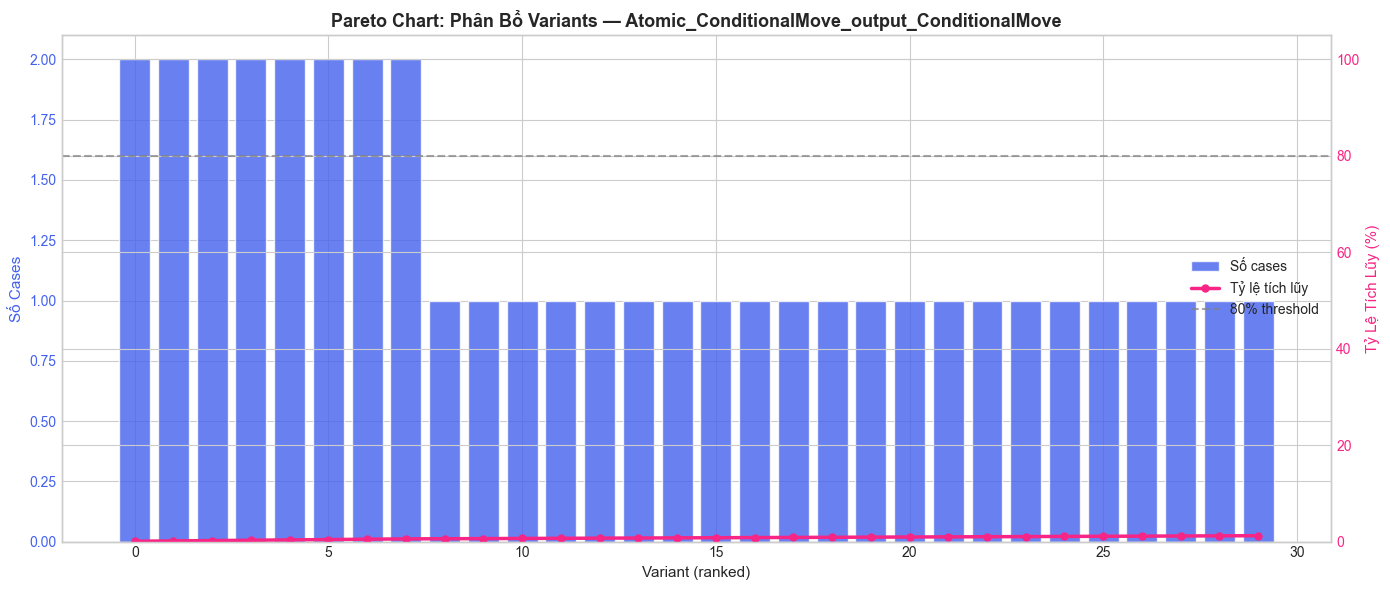

💾 Đã lưu: ostovar_variants_pareto.png


In [20]:
# ── Pareto chart: Coverage variants ──
fig, ax1 = plt.subplots(figsize=(14, 6))

top_n = min(30, len(variants_df))
top_variants = variants_df.head(top_n)

ax1.bar(range(len(top_variants)), top_variants['count'],
        color=PALETTE[0], alpha=0.8, edgecolor='white', label='Số cases')
ax1.set_xlabel('Variant (ranked)', fontsize=11)
ax1.set_ylabel('Số Cases', fontsize=11, color=PALETTE[0])
ax1.tick_params(axis='y', labelcolor=PALETTE[0])

ax2 = ax1.twinx()
ax2.plot(range(len(top_variants)), top_variants['cumulative_pct'],
         color=PALETTE[1], linewidth=2.5, marker='o', markersize=5, label='Tỷ lệ tích lũy')
ax2.axhline(80, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, label='80% threshold')
ax2.set_ylabel('Tỷ Lệ Tích Lũy (%)', fontsize=11, color=PALETTE[1])
ax2.tick_params(axis='y', labelcolor=PALETTE[1])
ax2.set_ylim(0, 105)

ax1.set_title(f'Pareto Chart: Phân Bổ Variants — {SAMPLE_LOG_NAME[:45]}', fontsize=13, fontweight='bold')

# Chú thích số variant để cover 80%
mask_80 = variants_df[variants_df['cumulative_pct'] >= 80]
idx_80 = mask_80.index[0] if len(mask_80) > 0 else None
if idx_80 is not None and idx_80 < top_n:
    ax1.axvline(idx_80, color='orange', linestyle='--', linewidth=2, label=f'80% ở variant #{idx_80+1}')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right', fontsize=10)

plt.tight_layout()
plt.savefig('ostovar_variants_pareto.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Đã lưu: ostovar_variants_pareto.png")

## 8. Heatmap Tổng Hợp: So Sánh Tất Cả Logs (Multi-Dimensional)

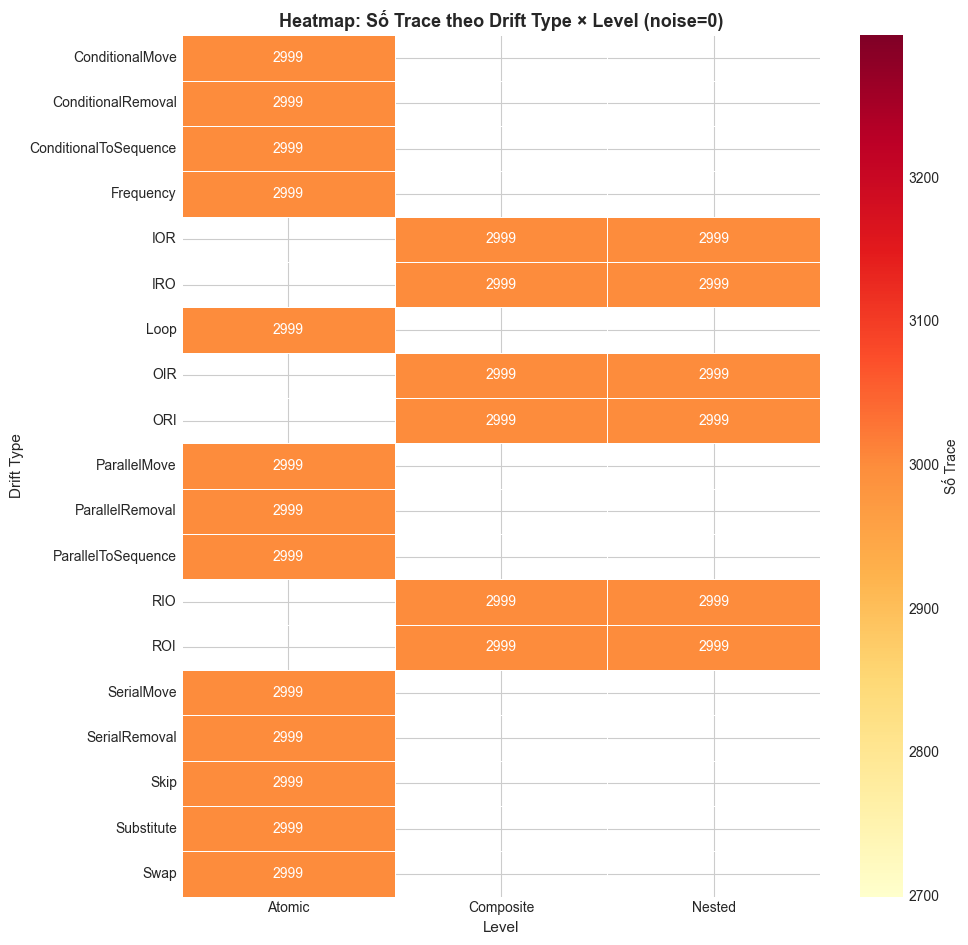

💾 Đã lưu: ostovar_heatmap_n_traces.png


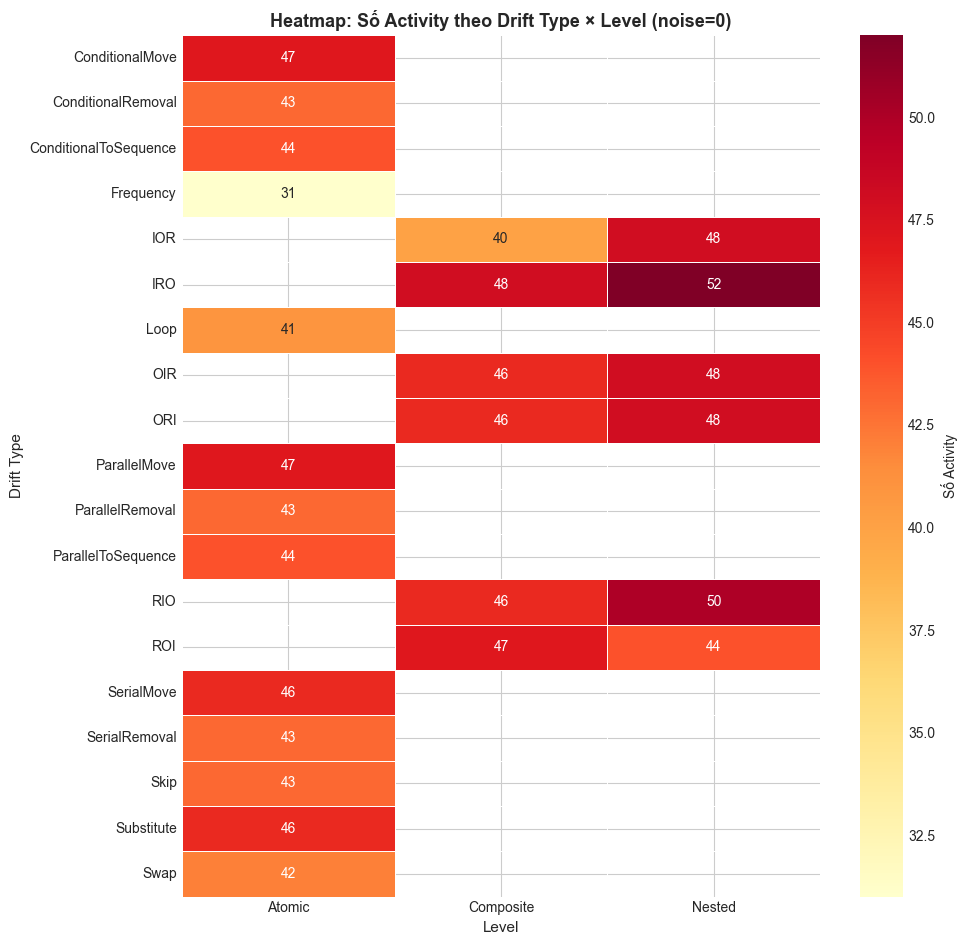

💾 Đã lưu: ostovar_heatmap_n_activities.png


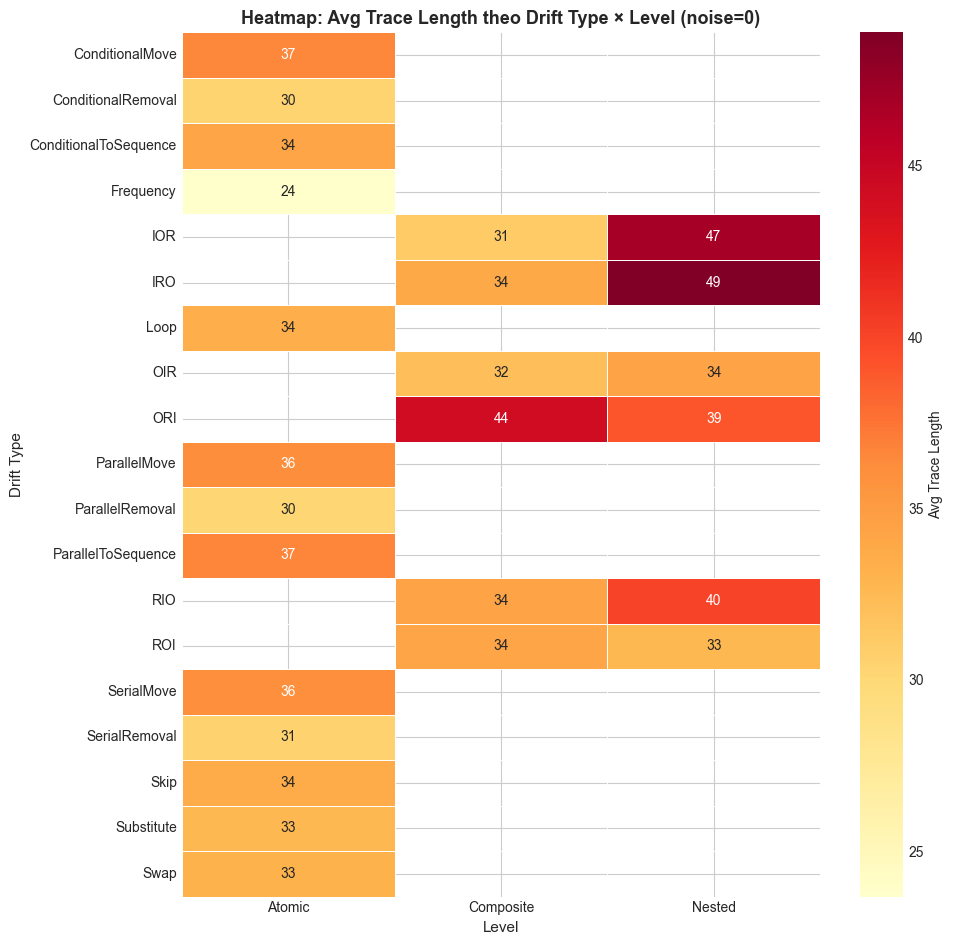

💾 Đã lưu: ostovar_heatmap_trace_len_mean.png


In [21]:
# Dùng dữ liệu all_stats_df để vẽ heatmap tổng hợp
heat_df = all_ok.copy() if 'all_ok' in dir() else ok_df.copy()

# Pivot: drift_type × level → avg trace length (hoặc n_traces)
for metric, metric_label in [('n_traces', 'Số Trace'), ('n_activities', 'Số Activity'), ('trace_len_mean', 'Avg Trace Length')]:
    pivot = heat_df[heat_df['noise_pct'] == 0].pivot_table(
        index='drift_type',
        columns='level',
        values=metric,
        aggfunc='mean'
    )
    
    fig, ax = plt.subplots(figsize=(10, max(6, len(pivot) * 0.45 + 1)))
    sns.heatmap(
        pivot,
        annot=True,
        fmt='.0f',
        cmap='YlOrRd',
        linewidths=0.5,
        linecolor='white',
        ax=ax,
        cbar_kws={'label': metric_label}
    )
    ax.set_title(f'Heatmap: {metric_label} theo Drift Type × Level (noise=0)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Level', fontsize=11)
    ax.set_ylabel('Drift Type', fontsize=11)
    plt.tight_layout()
    fname = f'ostovar_heatmap_{metric}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"💾 Đã lưu: {fname}")

## 9. Xuất Báo Cáo Tổng Hợp (CSV)

In [22]:
# ── Xuất catalog đầy đủ ──
export_df = all_ok[[
    'filename', 'level', 'drift_type', 'noise_pct', 'size_kb',
    'n_traces', 'n_events', 'n_activities',
    'trace_len_min', 'trace_len_max', 'trace_len_mean', 'trace_len_std', 'trace_len_median',
    'duration_days'
]].copy()

export_df.to_csv('ostovar_catalog_full.csv', index=False, encoding='utf-8-sig')
print(f"💾 Đã xuất: ostovar_catalog_full.csv ({len(export_df)} dòng)")

# ── Xuất summary theo (level × drift_type × noise) ──
summary_export = export_df.groupby(['level', 'drift_type', 'noise_pct']).agg(
    n_logs          = ('filename', 'count'),
    avg_n_traces    = ('n_traces', 'mean'),
    avg_n_events    = ('n_events', 'mean'),
    avg_n_activities= ('n_activities', 'mean'),
    avg_trace_len   = ('trace_len_mean', 'mean'),
    avg_size_kb     = ('size_kb', 'mean'),
).round(2).reset_index()

summary_export.to_csv('ostovar_summary_by_group.csv', index=False, encoding='utf-8-sig')
print(f"💾 Đã xuất: ostovar_summary_by_group.csv ({len(summary_export)} dòng)")

print("\n" + "═" * 60)
print("📊 TỔNG KẾT PHÂN TÍCH SƠ BỘ OSTOVAR DATASET")
print("═" * 60)
print(f"  Tổng số log file:     75")
print(f"  Cấp độ drift:         Atomic | Composite | Nested")
print(f"  Loại noise:           0% (baseline) | 2% | 5%")
print(f"  Định dạng:            XES (gzip compressed)")
print(f"  Mục đích:             Benchmark Concept Drift Detection")
print(f"  Tổng trace đọc được:  {export_df['n_traces'].sum():,}")
print(f"  Tổng event đọc được:  {export_df['n_events'].sum():,}")
print(f"  File đã lưu:")
print(f"    ✅ ostovar_catalog_full.csv")
print(f"    ✅ ostovar_summary_by_group.csv")
print(f"    ✅ ostovar_all_stats_cache.csv")
print(f"    ✅ ostovar_structure_overview.png")
print(f"    ✅ ostovar_comparison.png")
print(f"    ✅ ostovar_noise_effect.png")
print(f"    ✅ ostovar_deepdive_sample.png")
print(f"    ✅ ostovar_variants_pareto.png")
print(f"    ✅ ostovar_heatmap_*.png")
print("═" * 60)

💾 Đã xuất: ostovar_catalog_full.csv (75 dòng)
💾 Đã xuất: ostovar_summary_by_group.csv (75 dòng)

════════════════════════════════════════════════════════════
📊 TỔNG KẾT PHÂN TÍCH SƠ BỘ OSTOVAR DATASET
════════════════════════════════════════════════════════════
  Tổng số log file:     75
  Cấp độ drift:         Atomic | Composite | Nested
  Loại noise:           0% (baseline) | 2% | 5%
  Định dạng:            XES (gzip compressed)
  Mục đích:             Benchmark Concept Drift Detection
  Tổng trace đọc được:  224,925
  Tổng event đọc được:  8,070,462
  File đã lưu:
    ✅ ostovar_catalog_full.csv
    ✅ ostovar_summary_by_group.csv
    ✅ ostovar_all_stats_cache.csv
    ✅ ostovar_structure_overview.png
    ✅ ostovar_comparison.png
    ✅ ostovar_noise_effect.png
    ✅ ostovar_deepdive_sample.png
    ✅ ostovar_variants_pareto.png
    ✅ ostovar_heatmap_*.png
════════════════════════════════════════════════════════════


## 10. Checklist Các Bước Tiếp Theo

Sau khi hoàn thành EDA sơ bộ, các hướng phân tích tiếp theo:

### 🔬 Process Discovery
- [ ] Khám phá Petri net / DFG của mỗi nhóm drift type
- [ ] So sánh model **trước và sau** điểm drift (split log tại midpoint)
- [ ] Dùng **Inductive Miner Infrequent (IMf)** cho noise logs

### 📈 Drift Detection
- [ ] Áp dụng **ADWIN** (Adaptive Windowing) để phát hiện điểm drift
- [ ] Áp dụng **CUSUM** trên các feature thống kê của trace
- [ ] Thử **ProDrift** / **CD-MMD** với sliding window
- [ ] So sánh precision/recall phát hiện drift giữa Atomic vs Composite vs Nested

### 🎯 Conformance Checking
- [ ] Token-based replay trên model trước drift vs log sau drift
- [ ] Tính fitness, precision, generalization, simplicity
- [ ] Phân tích deviation pattern theo từng loại drift

### 🤖 Machine Learning
- [ ] Feature engineering: trace-level statistics làm input
- [ ] Classify drift type từ log statistics
- [ ] Temporal clustering để nhóm traces theo giai đoạn drift

---

> **💡 Lưu ý quan trọng:**
> Bộ dataset Ostovar được thiết kế có điểm drift **đã biết trước** (controlled). Khi benchmark thuật toán, cần so sánh điểm drift phát hiện được vs điểm drift thực tế để tính `detection lag` và `false positive rate`.